In [1]:
import argparse
import os
import yaml
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms.v2 as T
from torch.utils.data import DataLoader, random_split
import torch
import torchvision.transforms.v2 as T
import torchvision.transforms.v2.functional as F
from torchvision import tv_tensors
from torch.utils.data import Dataset
import os
from PIL import Image
import random
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Dataset Klasse + DataLoader
Generator Klasse
Discriminator Klasse
Loss Funktionen
Trainingsschleife
Plot Funktion
Metrik Funktion
Checkpoint Funktion

In [3]:
class Rice2(Dataset):
    def __init__(self, data_dir):
        self.label_dir = data_dir + "/label"
        self.cloud_dir = data_dir + "/cloud"
        self.mask_dir = data_dir + "/mask"
        self.ids = sorted(os.listdir(self.cloud_dir))

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        name = self.ids[idx]

        cloudy = Image.open(os.path.join(self.cloud_dir, name)).convert("RGB")
        label = Image.open(os.path.join(self.label_dir, name)).convert("RGB")
        mask = Image.open(os.path.join(self.mask_dir, name)).convert("L")

        cloudy = F.resize(cloudy, (256, 256))
        label = F.resize(label, (256, 256))
        mask = F.resize(mask, (256, 256))

        # *2-1 to scale from [0, 1] to [-1, 1]
        cloudy = F.to_tensor(cloudy) * 2 - 1
        label = F.to_tensor(label) * 2 - 1
        mask = (F.to_tensor(mask) > 0.5).float()

        return cloudy, label, mask

In [4]:
data_dir = "/home/christopher/sync/projekte/GNN_projekt/RICE_DATASET/RICE2"
dataset = Rice2(data_dir)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
training_data, val_data = random_split(
    dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)


train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=64, shuffle=True)

In [5]:
def plot_images(dataloader, n_img):
    cloudy, label, mask = next(iter(dataloader))
    for i in range(n_img):
        fig, axs = plt.subplots(1, 3, figsize=(12, 4))
        axs[0].imshow(cloudy[i].permute(1, 2, 0) * 0.5 + 0.5)
        axs[0].set_title("Cloudy Image")
        axs[0].axis("off")

        axs[1].imshow(label[i].permute(1, 2, 0) * 0.5 + 0.5)
        axs[1].set_title("Label Image")
        axs[1].axis("off")

        axs[2].imshow(mask[i][0], cmap="gray")
        axs[2].set_title("Mask Image")
        axs[2].axis("off")

        plt.show()

/home/christopher/Venv/venv/lib64/python3.10/site-packages/torchvision/transforms/v2/functional/_deprecated.py:12: UserWarning: The function `to_tensor(...)` is deprecated and will be removed in a future release. Instead, please use `to_image(...)` followed by `to_dtype(..., dtype=torch.float32, scale=True)`.
  warnings.warn(


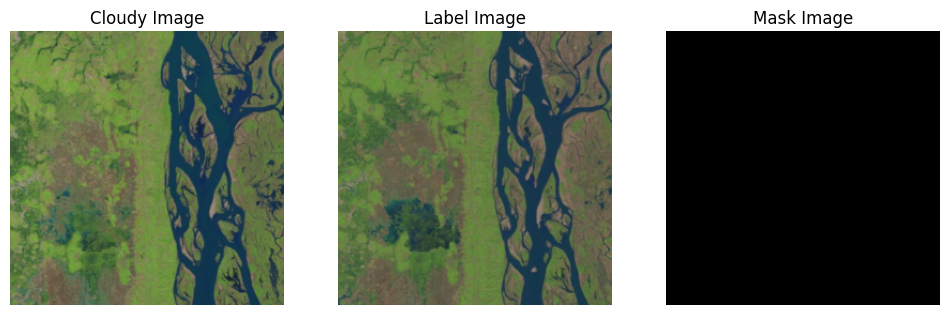

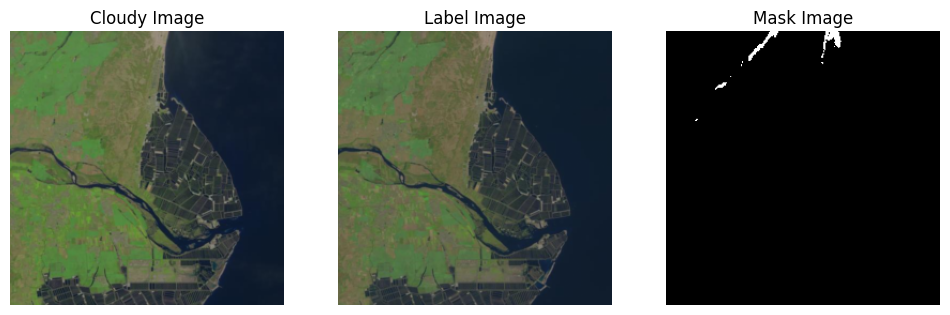

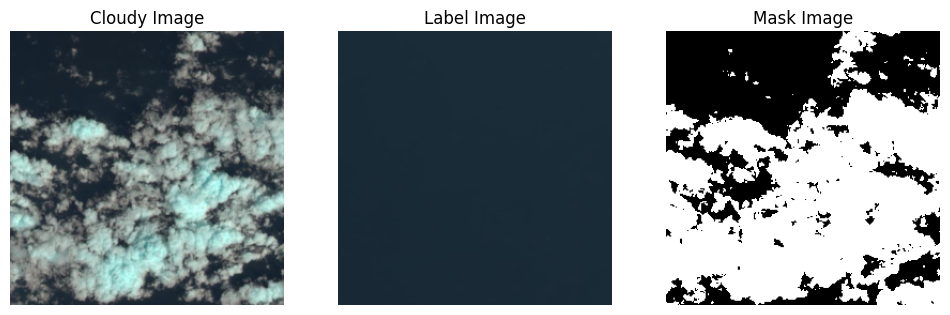

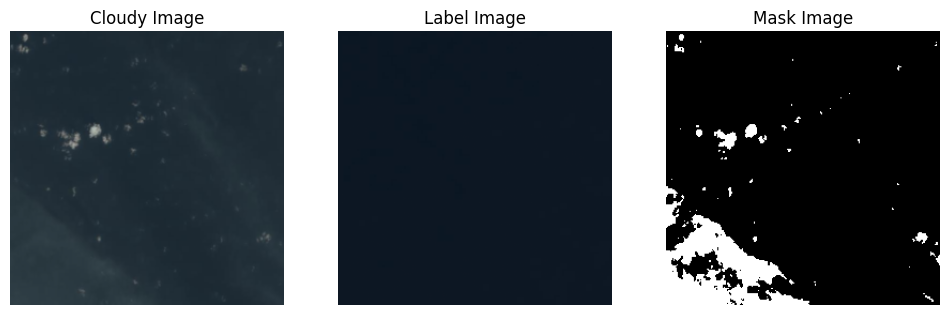

In [6]:
plot_images(train_dataloader, 4)

In [7]:
class Encoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.conv1 = nn.Conv2d(
            6, 32, kernel_size=4, stride=2, padding=1
        )  # 256x256 -> 128x128
        self.conv2 = nn.Conv2d(
            32, 64, kernel_size=4, stride=2, padding=1
        )  # 128x128 -> 64x64
        self.conv3 = nn.Conv2d(
            64, 128, kernel_size=4, stride=2, padding=1
        )  # 64x64 -> 32x32
        self.conv4 = nn.Conv2d(
            128, 248, kernel_size=4, stride=2, padding=1
        )  # 32x32 -> 16x16
        self.leaky_relu = nn.LeakyReLU(0.2)
        self.linear_mu = nn.Linear(248 * 16 * 16, latent_dim)
        self.linear_logvar = nn.Linear(248 * 16 * 16, latent_dim)

    def forward(self, cloudy, label):
        x = torch.cat((cloudy, label), dim=1)  # Concatenate along the channel dimension
        x = self.leaky_relu(self.conv1(x))
        x = self.leaky_relu(self.conv2(x))
        x = self.leaky_relu(self.conv3(x))
        x = self.leaky_relu(self.conv4(x))
        x = x.view(x.size(0), -1)
        mu = self.linear_mu(x)
        logvar = self.linear_logvar(x)
        return mu, logvar

In [8]:
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

In [9]:
class Decoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.linear = nn.Linear(latent_dim, 248 * 16 * 16)
        self.conv1 = nn.ConvTranspose2d(
            248 + 3, 128, kernel_size=4, stride=2, padding=1
        )
        self.conv2 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)
        self.conv3 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        self.conv4 = nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1)
        self.leaky_relu = nn.LeakyReLU(0.2)
        self.tanh = nn.Tanh()

    def forward(self, z, label):
        x = self.leaky_relu(self.linear(z))
        x = x.view(-1, 248, 16, 16)
        label = nn.functional.interpolate(
            label, size=(16, 16), mode="bilinear", align_corners=False
        )
        x = torch.cat((x, label), dim=1)  # Concatenate along the channel dimension
        x = self.leaky_relu(self.conv1(x))
        x = self.leaky_relu(self.conv2(x))
        x = self.leaky_relu(self.conv3(x))
        x = self.tanh(self.conv4(x))
        return x

In [10]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)
        self.latent_dim = latent_dim

    def forward(self, cloudy, label):
        mu, logvar = self.encoder(cloudy, label)
        z = reparameterize(mu, logvar)
        output = self.decoder(z, cloudy)
        return output, mu, logvar

    def generate(self, cloudy):
        z = torch.randn(cloudy.size(0), self.latent_dim).to(cloudy.device)
        output = self.decoder(z, cloudy)
        return output

In [11]:
def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    recon_loss = nn.MSELoss()(recon_x, x)
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl_loss, recon_loss, kl_loss

In [12]:
def denorm(x):
    # von [-1, 1] zurück nach [0, 1] für die Anzeige
    return (x.clamp(-1, 1) + 1) / 2

In [13]:
def plot_losses(model, train_losses, val_losses, model_name="Model", save_path=None):
    """
    Plot training and validation losses over epochs.
    Parameters:
    - model: The trained model.
    - train_losses: List of training losses per epoch.
    - val_losses: List of validation losses per epoch.
    - model_name: Name of the model for the plot title.
    """
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.ylim(0, 0.8)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training and Validation Loss over Epochs for {model_name}")
    plt.legend()
    if save_path:
        plt.savefig(save_path)
    plt.show()

In [14]:
def plot_samples(model, val_dataloader, device, epoch, n=4):
    model.eval()
    cloudy, label, mask = next(iter(val_dataloader))
    cloudy, label = cloudy.to(device), label.to(device)

    with torch.no_grad():
        recon, _, _ = model(cloudy, label)   # mit Encoder (konvergiert schneller)
        gen = model.generate(cloudy)          # z aus N(0,1) (Testzeit)

    cloudy = denorm(cloudy.cpu())
    label  = denorm(label.cpu())
    recon  = denorm(recon.cpu())
    gen    = denorm(gen.cpu())

    rows = [
        ("Cloudy", cloudy),
        ("Reconstruction (Encoder)", recon),
        ("Generation (z~N(0,1))", gen),
        ("Ground Truth", label),
    ]

    fig, axes = plt.subplots(len(rows), n, figsize=(n * 3, len(rows) * 3))
    for r, (title, imgs) in enumerate(rows):
        for i in range(n):
            axes[r, i].imshow(imgs[i].permute(1, 2, 0))
            axes[r, i].axis("off")
            if i == 0:
                axes[r, i].set_ylabel(title, rotation=0, ha="right", va="center")
        axes[r, 0].set_title(title, loc="left", fontsize=10)
    fig.suptitle(f"Epoch {epoch+1}")
    plt.tight_layout()
    plt.show()

In [15]:
model = Autoencoder(latent_dim=128).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 20
train_losses = []
val_losses = []

In [16]:
import matplotlib.pyplot as plt


def denorm(x):
    # von [-1, 1] zurück nach [0, 1] für die Anzeige
    return (x.clamp(-1, 1) + 1) / 2


def plot_samples(model, val_dataloader, device, epoch, n=4):
    model.eval()
    cloudy, label, mask = next(iter(val_dataloader))
    cloudy, label = cloudy.to(device), label.to(device)

    with torch.no_grad():
        recon = model.generate(cloudy)  # Testzeit: z aus N(0,1)

    cloudy = denorm(cloudy.cpu())
    label = denorm(label.cpu())
    recon = denorm(recon.cpu())

    fig, axes = plt.subplots(3, n, figsize=(n * 3, 9))
    for i in range(n):
        axes[0, i].imshow(cloudy[i].permute(1, 2, 0))
        axes[0, i].set_title("Cloudy")
        axes[1, i].imshow(recon[i].permute(1, 2, 0))
        axes[1, i].set_title("Reconstruction")
        axes[2, i].imshow(label[i].permute(1, 2, 0))
        axes[2, i].set_title("Ground Truth")
        for row in range(3):
            axes[row, i].axis("off")
    fig.suptitle(f"Epoch {epoch+1}")
    plt.tight_layout()
    plt.show()


for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for cloudy, label, mask in train_dataloader:
        cloudy, label = cloudy.to(device), label.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(cloudy, label)
        loss, recon_loss, kl_loss = vae_loss(recon, label, mu, logvar)  # label!
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_train_loss = total_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)

    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for cloudy, label, mask in val_dataloader:
            cloudy, label = cloudy.to(device), label.to(device)
            recon, mu, logvar = model(cloudy, label)
            loss, recon_loss, kl_loss = vae_loss(recon, label, mu, logvar)  # label!
            total_val_loss += loss.item()
    avg_val_loss = total_val_loss / len(val_dataloader)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}"
    )

    # Outputs plotten
    plot_samples(model, val_dataloader, device, epoch)

KeyboardInterrupt: 